In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import duckdb as dcb
from plotly.data import wind

from shared.database_file.set_up import Setup

vérifier distance max et météo correspondante décollage

In [41]:
connector = Setup().get_duckdb_conn()
fact_flight = connector.query("""SELECT * FROM vayora_dw.fact_flight ff
                              JOIN vayora_dw.dim_pilot dp ON dp.dim_pilot_sk = ff.fact_flight_pilot
                              JOIN vayora_dw.dim_takeoff dt ON dt.dim_takeoff_sk = ff.fact_flight_takeoff
                              JOIN vayora_dw.dim_weather dw on dw.dim_weather_sk = ff.fact_flight_weather
                              JOIN vayora_dw.dim_date dd ON dd.date_key = ff.fact_flight_start_date
                              JOIN vayora_dw.dim_time dtm on dtm.time_key = ff.fact_flight_start_time"""
                              ).df()

In [4]:
weather_df = connector.query("""SELECT * FROM weather.weather_historic""").df()

In [42]:
fact_flight["dim_takeoff_name"].unique()

<StringArray>
[            'brandeville',                  'salève',
                    'treh',               'st. andré',
                'marcourt',                 'grauves',
                'la rhune',              'velars est',
                 'sur cou',                 'drumont',
 ...
         'osmoy st valery', 'saint hilaire du touvet',
           'port à binson',               'houeville',
                  'haulmé',        'terril du levant',
                   'dijon',                 'sinsans',
    'volmerange les mines',               'menez-hom']
Length: 111, dtype: str

<Axes: xlabel='wind_direction_800hpa'>

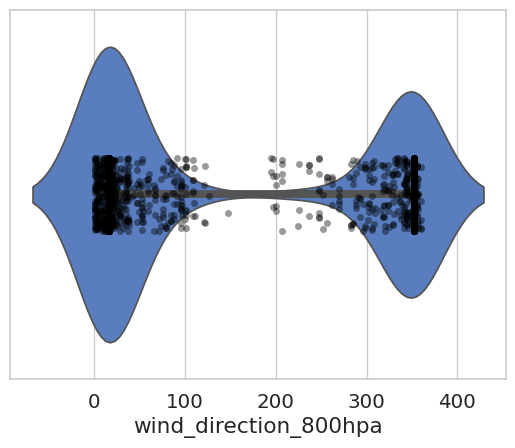

In [43]:
fact_flight_beauraing = fact_flight[fact_flight["dim_takeoff_name"] == "beauraing"]

sns.violinplot(data=fact_flight_beauraing, x="wind_direction_800hpa")
sns.stripplot(data=fact_flight_beauraing, x="wind_direction_800hpa", color="black", alpha=0.4)


<Axes: xlabel='wind_direction_800hpa'>

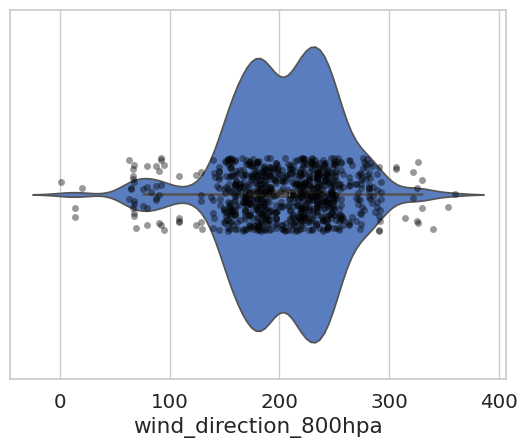

In [40]:
fact_flight_7 = fact_flight[fact_flight["dim_takeoff_name"] == "les sept meuses"]

sns.violinplot(data=fact_flight_7, x="wind_direction_800hpa")
sns.stripplot(data=fact_flight_7, x="wind_direction_800hpa", color="black", alpha=0.4)

<Axes: xlabel='wind_direction_800hpa'>

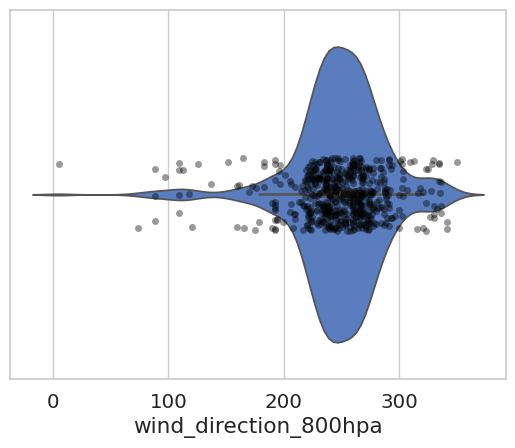

In [53]:
fact_flight_treh = fact_flight[(fact_flight["dim_takeoff_name"] == "treh") & (fact_flight['wind_speed_800hpa'] >= 10)]

sns.violinplot(data=fact_flight_treh, x="wind_direction_800hpa")
sns.stripplot(data=fact_flight_treh, x="wind_direction_800hpa", color="black", alpha=0.4)

<Axes: xlabel='wind_speed_800hpa'>

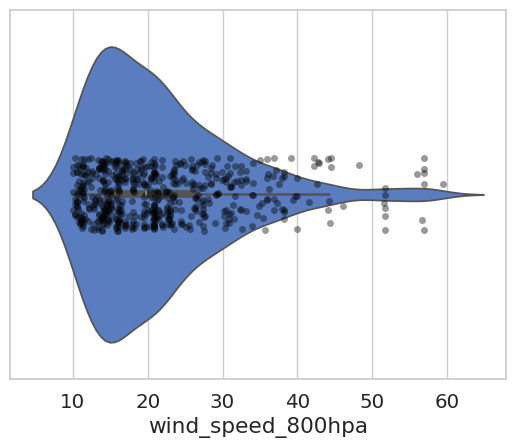

In [54]:
fact_flight_treh2 = fact_flight[(fact_flight["dim_takeoff_name"] == "treh") & (fact_flight['wind_speed_800hpa'] >= 10)]

sns.violinplot(data=fact_flight_treh2, x="wind_speed_800hpa")
sns.stripplot(data=fact_flight_treh2, x="wind_speed_800hpa", color="black", alpha=0.4)

In [55]:
fact_flight_treh[fact_flight_treh["wind_speed_800hpa"] > 35]

,fact_flight_sk,fact_flight_bk,fact_flight_distance,fact_flight_airtime,fact_flight_pilot,fact_flight_takeoff,fact_flight_weather,fact_flight_start_date,fact_flight_start_time,dim_pilot_sk,...,year_number,is_weekend,season,is_holiday_fwb,is_holiday_vl,time_key,full_time,hour_number,minute_number,period_of_day
1022,55290,109582,4,00:21:00,3167,7,1573541,20240619,1200,3167,...,2024,False,Summer,False,False,1200,12:00:00,12,0,Afternoon
1023,55364,109579,6,00:30:00,3167,7,1573542,20240619,1300,3167,...,2024,False,Summer,False,False,1300,13:00:00,13,0,Afternoon
1026,55294,132284,4,00:11:00,8943,7,1573571,20240620,1800,8943,...,2024,False,Summer,False,False,1800,18:00:00,18,0,Evening
1060,55328,33238,5,00:15:00,260,7,1574455,20240727,1300,260,...,2024,True,Summer,True,True,1300,13:00:00,13,0,Afternoon
1143,55291,121790,6,00:30:00,4904,7,1573542,20240619,1300,4904,...,2024,False,Summer,False,False,1300,13:00:00,13,0,Afternoon
27141,74718,127049,4,00:10:00,6317,7,1554342,20220411,1800,6317,...,2022,False,Spring,True,True,1800,18:00:00,18,0,Evening
27181,54813,69917,8,00:39:00,845,7,1555535,20220531,1100,845,...,2022,False,Spring,False,False,1100,11:00:00,11,0,Morning
27182,54814,69921,8,00:55:00,845,7,1555558,20220601,1000,845,...,2022,False,Summer,False,False,1000,10:00:00,10,0,Morning
27224,54816,114457,5,00:18:00,3741,7,1555727,20220608,1100,3741,...,2022,False,Summer,False,False,1100,11:00:00,11,0,Morning
27453,55178,86138,8,00:58:00,1540,7,1565279,20230711,1200,1540,...,2023,False,Summer,True,True,1200,12:00:00,12,0,Afternoon


In [52]:
fact_flight[fact_flight['wind_speed_800hpa'] >= 10].groupby('dim_takeoff_name')['wind_direction_800hpa'].median()

dim_takeoff_name
aiguebelette            232.900
allevard                227.390
andenne                  53.130
argeliers               202.415
aubas                    35.100
                         ...   
terril du levant         82.310
treh                    248.500
velars est               60.830
vierville sur mer        43.580
volmerange les mines    125.840
Name: wind_direction_800hpa, Length: 109, dtype: float64

In [51]:
fact_flight.groupby('dim_takeoff_name')['wind_direction_800hpa'].mean()

dim_takeoff_name
aiguebelette            219.680099
allevard                215.472617
andenne                  86.992195
argeliers               200.968125
aubas                   134.678966
                           ...    
terril du levant        120.682500
treh                    248.224695
velars est              101.808889
vierville sur mer        91.474211
volmerange les mines    131.283246
Name: wind_direction_800hpa, Length: 109, dtype: float64

In [46]:
fact_flight.info()

<class 'pandas.DataFrame'>
Index: 33670 entries, 0 to 99983
Data columns (total 76 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   fact_flight_sk              33670 non-null  int32         
 1   fact_flight_bk              33670 non-null  int32         
 2   fact_flight_distance        33670 non-null  int32         
 3   fact_flight_airtime         33670 non-null  object        
 4   fact_flight_pilot           33670 non-null  int32         
 5   fact_flight_takeoff         33670 non-null  int32         
 6   fact_flight_weather         33670 non-null  int32         
 7   fact_flight_start_date      33670 non-null  int32         
 8   fact_flight_start_time      33670 non-null  int32         
 9   dim_pilot_sk                33670 non-null  int32         
 10  dim_pilot_bk                33670 non-null  int32         
 11  dim_pilot_maxdistance       33670 non-null  int32         
 12  dim_pi

In [56]:
fact_flight.to_csv("vayora_fact_flight.csv", encoding="utf-8", index=False)

In [ ]:
fact_flight

In [44]:
fact_flight = fact_flight.drop("precipitation_probability",axis=1)

In [45]:
cols = fact_flight.columns.difference(['fact_flight_bk', 'fact_flight_sk'])
fact_flight = fact_flight.drop_duplicates(subset=cols, keep='first')
fact_flight.info()

<class 'pandas.DataFrame'>
Index: 33670 entries, 0 to 99983
Data columns (total 76 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   fact_flight_sk              33670 non-null  int32         
 1   fact_flight_bk              33670 non-null  int32         
 2   fact_flight_distance        33670 non-null  int32         
 3   fact_flight_airtime         33670 non-null  object        
 4   fact_flight_pilot           33670 non-null  int32         
 5   fact_flight_takeoff         33670 non-null  int32         
 6   fact_flight_weather         33670 non-null  int32         
 7   fact_flight_start_date      33670 non-null  int32         
 8   fact_flight_start_time      33670 non-null  int32         
 9   dim_pilot_sk                33670 non-null  int32         
 10  dim_pilot_bk                33670 non-null  int32         
 11  dim_pilot_maxdistance       33670 non-null  int32         
 12  dim_pi

In [15]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.3)

In [51]:
fact_flight['diff_temperature'] = fact_flight["temperature_950hpa"] - fact_flight["temperature_800hpa"]
fact_flight['diff_wind_speed'] = fact_flight['wind_speed_950hpa'] - fact_flight['wind_speed_800hpa']
fact_flight['diff_humidity'] = fact_flight['relative_humidity_950hpa'] - fact_flight['relative_humidity_800hpa']
fact_flight['diff_cloudcover'] = fact_flight['cloud_cover_950hpa'] - fact_flight['cloud_cover_800hpa']

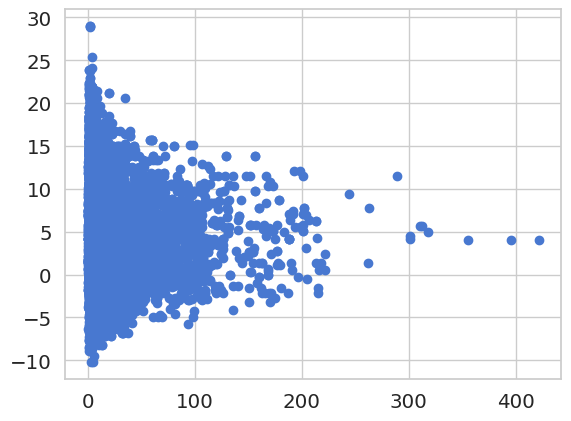

In [10]:
plt.scatter(fact_flight["fact_flight_distance"], fact_flight["lifted_index"], )

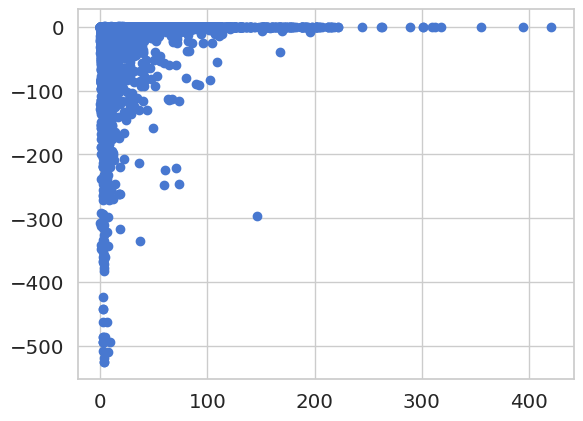

In [11]:
plt.scatter(fact_flight["fact_flight_distance"], fact_flight["convective_inhibition"], )

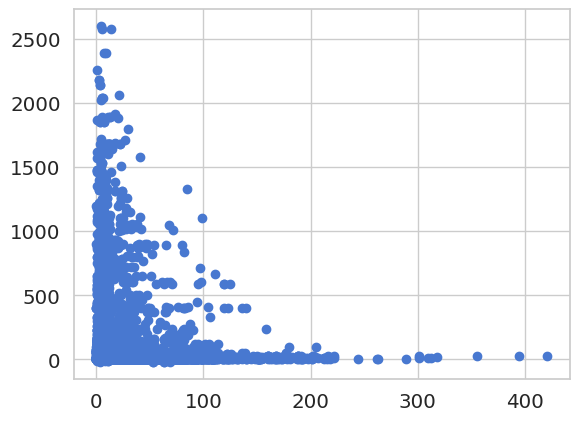

In [12]:
plt.scatter(fact_flight["fact_flight_distance"], fact_flight["cape"], )

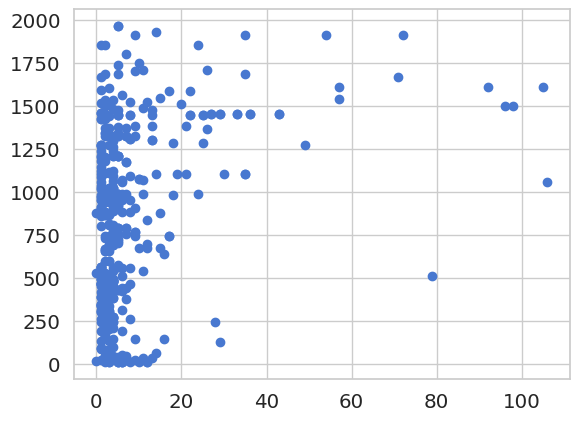

In [61]:
plt.scatter(fact_flight["fact_flight_distance"], fact_flight["boundary_layer_height"], )

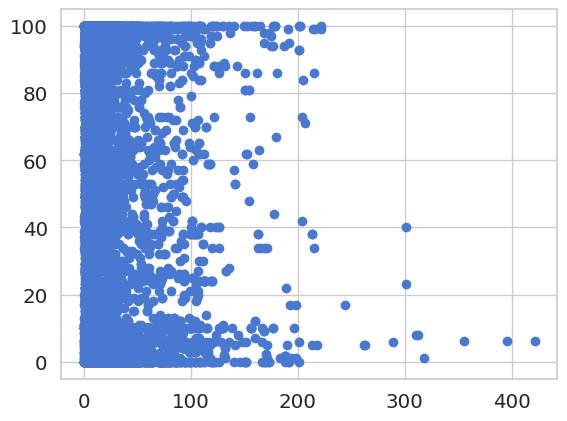

In [68]:
plt.scatter(fact_flight["fact_flight_distance"], fact_flight["cloud_cover"], )

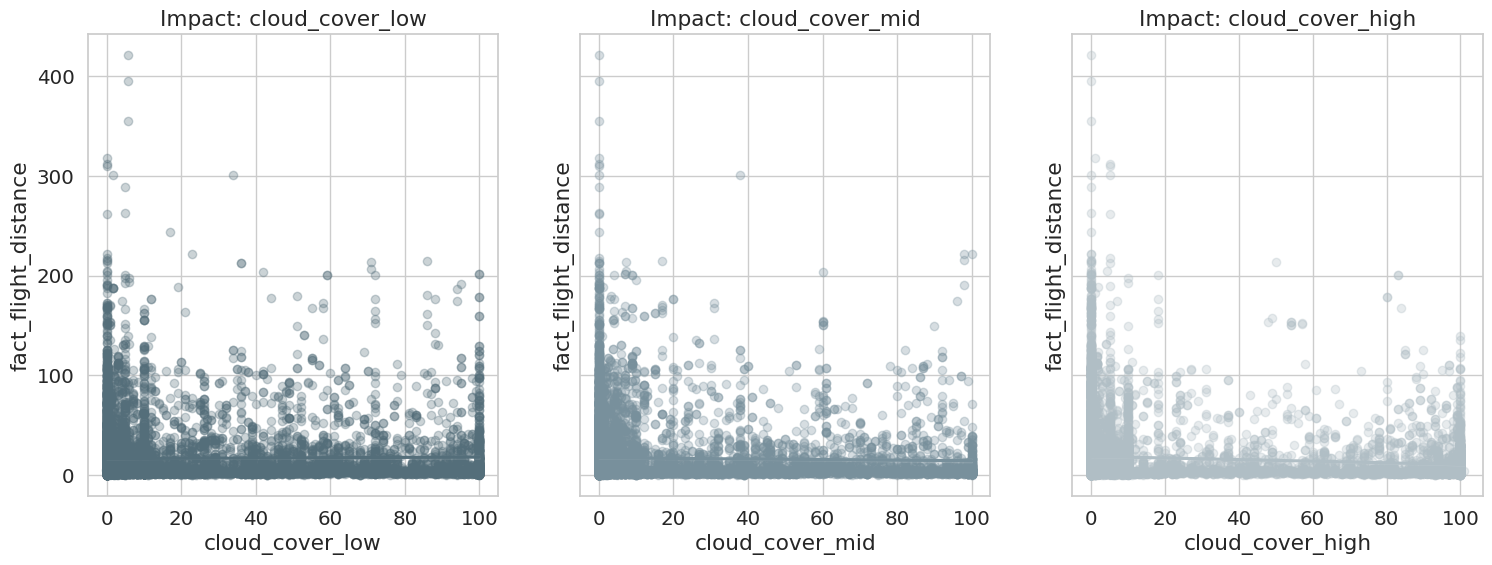

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
layers = ['cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high']
colors = ['#546e7a', '#78909c', '#b0bec5'] # Du plus sombre/bas au plus clair/haut

for i, layer in enumerate(layers):
    sns.regplot(data=fact_flight, x=layer, y='fact_flight_distance',
                ax=axes[i], color=colors[i], scatter_kws={'alpha':0.3})
    axes[i].set_title(f'Impact: {layer}')

Text(0.5, 0, 'Tranche de distance (km)')

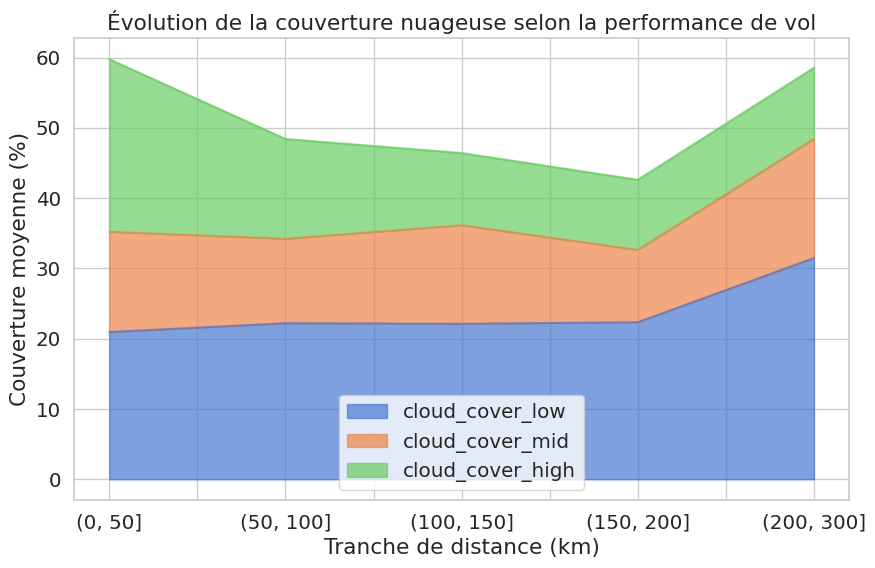

In [70]:
# 1. Création des tranches de distance
fact_flight['dist_bin'] = pd.cut(fact_flight['fact_flight_distance'],
                                 bins=[0, 50, 100, 150, 200, 300])

# 2. Groupby et moyenne
df_plot = fact_flight.groupby('dist_bin')[['cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high']].mean()

# 3. Plot
df_plot.plot(kind='area', stacked=True, figsize=(10, 6), alpha=0.7)
plt.title("Évolution de la couverture nuageuse selon la performance de vol")
plt.ylabel("Couverture moyenne (%)")
plt.xlabel("Tranche de distance (km)")

In [65]:
test_dist100 = fact_flight[fact_flight["fact_flight_distance"] >= 100]
test_dist150 = fact_flight[fact_flight["fact_flight_distance"] >= 150]
test_dist200 = fact_flight[fact_flight["fact_flight_distance"] > 300]

In [66]:
# Colonnes pertinentes pour la corrélation
corr_cols = [
    # Cibles
    "fact_flight_distance",

    # Temporel
    "month_number",

    # Météo surface
    "convective_inhibition",
    "cloud_cover",
    "cape",
    "lifted_index",
    "relative_humidity_600hpa",
    "relative_humidity_950hpa",
    "boundary_layer_height"
]

corr_matrix1 = fact_flight[corr_cols].corr()
corr_matrix2 = test_dist100[corr_cols].corr()
corr_matrix3 = test_dist150[corr_cols].corr()
corr_matrix4 = test_dist200[corr_cols].corr()

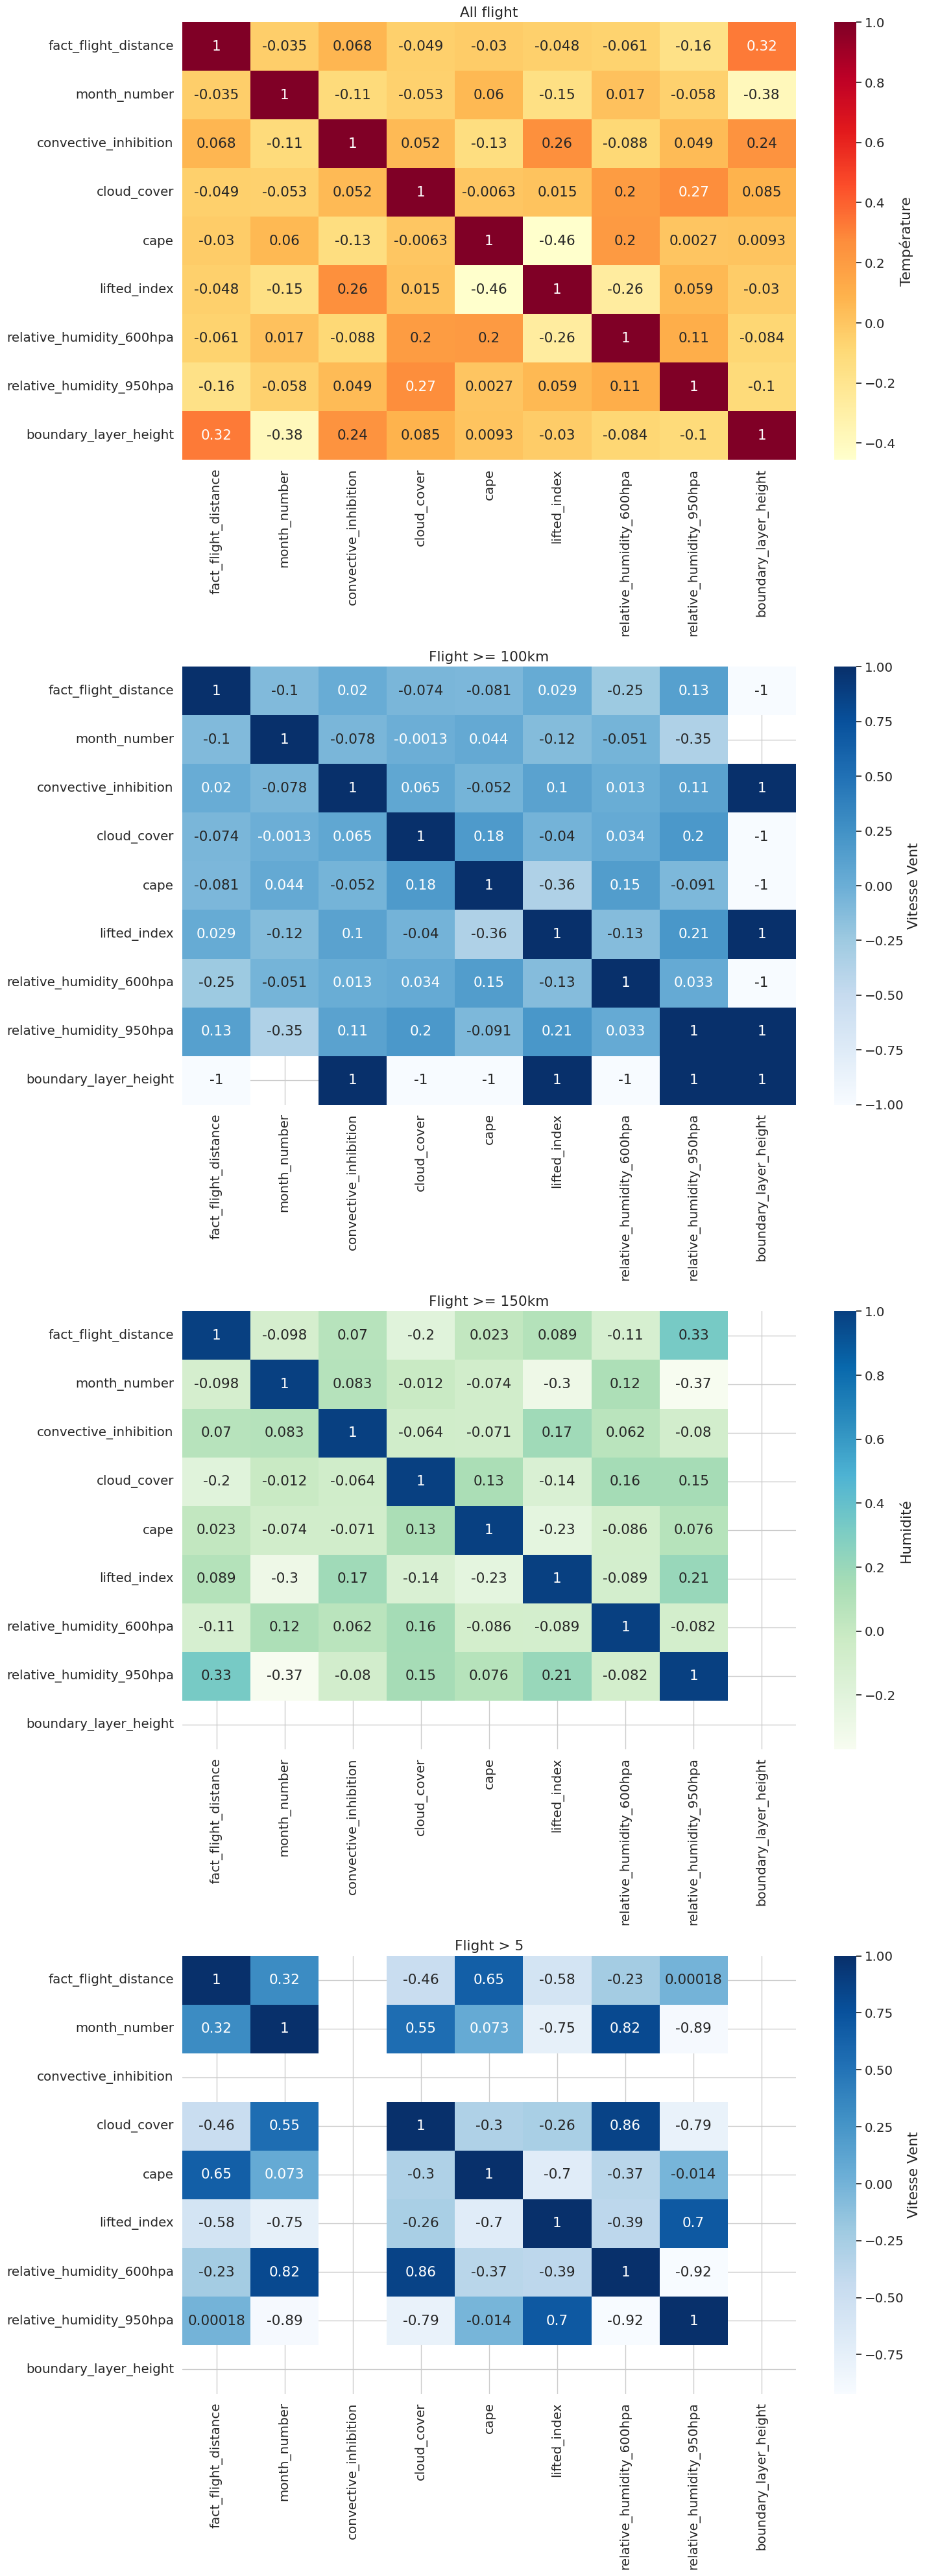

In [67]:
fig, axes = plt.subplots(4, 1, figsize=(15, 40))

sns.heatmap(corr_matrix1, ax=axes[0], cmap='YlOrRd', cbar_kws={'label': 'Température'}, annot=True)
axes[0].set_title("All flight")

sns.heatmap(corr_matrix2, ax=axes[1], cmap='Blues', cbar_kws={'label': 'Vitesse Vent'}, annot=True)
axes[1].set_title('Flight >= 100km')

sns.heatmap(corr_matrix3, ax=axes[2], cmap='GnBu', cbar_kws={'label': 'Humidité'}, annot=True)
axes[2].set_title('Flight >= 150km')

sns.heatmap(corr_matrix4, ax=axes[3 ], cmap='Blues', cbar_kws={'label': 'Vitesse Vent'}, annot=True)
axes[3].set_title('Flight > 5')

plt.tight_layout()
plt.show()